In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor


In [71]:
dataset=pd.read_csv('editedab.csv',index_col=0)

In [72]:
dataset.head()

,DATE,TMR,GRASS,WATER,BATH,MILK
COWid,,,,,,
cow01,01-01-19,6.8,17.6,28.6,3,18.0
cow01,02-01-19,5.6,13.9,15.3,2,16.8
cow01,03-01-19,7.1,17.9,24.2,1,14.5
cow01,04-01-19,6.6,14.5,22.3,0,14.3
cow01,05-01-19,7.4,17.3,29.0,3,17.6


In [73]:

dataset.describe()

,TMR,GRASS,WATER,BATH,MILK
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,6.486250,15.795833,23.039167,1.833333,17.907083
std,0.610661,1.567659,4.069466,0.890050,2.276934
min,5.500000,13.000000,15.100000,0.000000,14.000000
25%,5.900000,14.400000,20.000000,1.000000,15.875000
50%,6.500000,15.900000,23.200000,2.000000,18.000000
75%,7.000000,17.100000,26.200000,3.000000,20.100000
max,8.600000,18.400000,30.000000,3.000000,22.000000


In [74]:
data_feature_names = ['TMR','GRASS','WATER','BATH','MILK']
target=['MILK']

In [75]:
X = dataset.iloc[:,1:5].values
y = dataset.iloc[:,len( dataset.iloc[0])-1].values

In [76]:
print(X)
print(y)

[[ 6.8 17.6 28.6  3. ]
 [ 5.6 13.9 15.3  2. ]
 [ 7.1 17.9 24.2  1. ]
 [ 6.6 14.5 22.3  0. ]
 [ 7.4 17.3 29.   3. ]
 [ 6.1 17.3 20.4  2. ]
 [ 5.7 17.6 28.6  0. ]
 [ 7.3 16.1 21.1  0. ]
 [ 7.  14.1 21.1  3. ]
 [ 5.6 13.7 22.9  3. ]
 [ 6.7 14.1 21.4  1. ]
 [ 7.1 13.8 24.   1. ]
 [ 6.1 17.1 23.8  1. ]
 [ 6.7 18.1 29.1  3. ]
 [ 6.9 14.2 24.1  0. ]
 [ 7.3 18.  25.4  1. ]
 [ 7.1 15.8 29.5  1. ]
 [ 5.8 18.4 25.   0. ]
 [ 7.3 18.4 22.2  2. ]
 [ 6.1 17.  27.2  3. ]
 [ 5.7 17.7 21.4  2. ]
 [ 6.4 15.9 29.1  0. ]
 [ 6.1 13.  23.6  3. ]
 [ 6.3 18.4 16.4  1. ]
 [ 5.9 17.9 19.7  2. ]
 [ 7.1 16.9 15.1  2. ]
 [ 6.8 14.5 27.1  3. ]
 [ 5.9 15.1 23.4  1. ]
 [ 6.2 17.3 20.9  1. ]
 [ 5.6 13.3 29.   0. ]
 [ 7.4 15.6 23.4  3. ]
 [ 5.8 13.1 27.9  2. ]
 [ 6.8 15.2 21.2  0. ]
 [ 5.9 16.3 18.1  1. ]
 [ 6.2 15.6 20.4  1. ]
 [ 6.7 16.5 15.9  0. ]
 [ 6.8 18.3 27.6  3. ]
 [ 6.3 14.8 21.5  1. ]
 [ 6.9 13.7 21.7  1. ]
 [ 6.6 17.3 15.3  2. ]
 [ 6.6 15.  16.8  1. ]
 [ 6.6 15.6 19.7  0. ]
 [ 5.6 17.1 19.5  0. ]
 [ 7.  16.1

In [77]:
# It randomly picks data to form the training and test set.
# To disable this feature, simply set the shuffle parameter as False (default = True).

In [78]:
from sklearn.model_selection import train_test_split  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [79]:
x1=X_train.shape
print(x1)
x2=X_test.shape
print(x2)
x3=y_train.shape
print(x3)
x4=y_test.shape
print(x4)

(192, 4)
(48, 4)
(192,)
(48,)


In [80]:
print(X_train)
print('\n')
print(X_test)

[[ 6.5 14.4 26.7  1. ]
 [ 6.4 15.2 29.   2. ]
 [ 6.9 17.9 22.5  1. ]
 [ 6.6 17.1 16.9  1. ]
 [ 7.2 16.  28.2  3. ]
 [ 7.5 17.4 22.9  1. ]
 [ 7.3 17.  26.2  3. ]
 [ 5.9 16.3 18.1  1. ]
 [ 5.8 17.4 29.   2. ]
 [ 6.1 13.4 26.1  1. ]
 [ 6.4 17.4 29.3  2. ]
 [ 7.5 15.  17.3  1. ]
 [ 7.  17.3 23.7  3. ]
 [ 5.6 16.9 21.3  2. ]
 [ 6.4 16.3 28.5  2. ]
 [ 5.8 14.1 21.6  1. ]
 [ 6.1 14.  21.6  2. ]
 [ 7.1 16.3 18.2  2. ]
 [ 7.1 15.8 29.5  1. ]
 [ 6.5 13.5 18.3  2. ]
 [ 6.3 15.8 20.5  2. ]
 [ 6.  17.6 15.6  2. ]
 [ 7.4 17.3 29.   3. ]
 [ 5.9 14.4 20.   2. ]
 [ 6.9 14.4 15.8  3. ]
 [ 6.8 15.5 17.4  3. ]
 [ 7.4 14.4 19.   1. ]
 [ 6.3 14.3 28.2  1. ]
 [ 6.8 14.5 27.1  3. ]
 [ 6.  17.  23.3  3. ]
 [ 6.5 16.9 23.1  1. ]
 [ 5.9 15.4 24.3  2. ]
 [ 6.6 15.  16.8  1. ]
 [ 6.7 18.1 29.1  3. ]
 [ 6.6 14.5 22.3  0. ]
 [ 6.  16.3 19.1  2. ]
 [ 5.9 17.9 19.7  2. ]
 [ 7.4 15.6 23.4  3. ]
 [ 6.2 18.3 16.2  2. ]
 [ 6.5 13.2 15.8  3. ]
 [ 6.2 14.2 21.8  2. ]
 [ 7.2 13.8 16.7  1. ]
 [ 6.7 17.9 22.2  3. ]
 [ 6.1 17. 

In [81]:
# Create a decision tree regressor and fit it to the training set


# 1) criterion=mse:- The function to measure the quality of a split.
#   Supported criteria are mse for the mean squared error, 
#   which is equal to variance reduction as feature selection criterion.

# 2) max-depth:- The maximum depth of the tree. 
#    If None, then nodes are expanded until all leaves are pure.

# 3) max-features:- The number of features to consider when looking for the best split.

# 4) min-impurity-decrease:- A node will be split if this split induces
#    a decrease of the impurity greater than or equal to this value.
#     [ N_t / N * (impurity - N_t_R / N_t * right_impurity
#     - N_t_L / N_t * left_impurity)]

#  { where N is the total number of samples, 
#  (N_t) is the number of samples at the current node
#  (N_t_L) is the number of samples in the left child, and 
#  (N_t_R) is the number of samples in the right child.}

# 5) min-impurity-split:- Threshold for early stopping in tree growth.
#   A node will split if its impurity is above the threshold, otherwise it is a leaf.

# 6) presort:- Whether to presort the data to speed up the finding of best splits in fitting.
# For the default settings of a decision setting this to true may slow down the training process. 

# 7) max-depth, min-samples-leaf, etc.:- The default values for the parameters controlling 
#    the size of the treeslead to fully grown and unpruned trees.
#    To reduce memory consumption, the complexity and size of the trees 
#    should be controlled by setting those parameter values.

# 8) random-state:- The features are always randomly permuted at each split.
#    Therefore, the best found split may vary, even with the same training data and max-features=n-features. 

from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(max_depth=1)
regressor.fit(X_train, y_train) 

DecisionTreeRegressor(criterion='mse', max_depth=1, max_features=None,
           max_leaf_nodes=None, min_impurity_decrease=0.0,
           min_impurity_split=None, min_samples_leaf=1,
           min_samples_split=2, min_weight_fraction_leaf=0.0,
           presort=False, random_state=None, splitter='best')

In [82]:
y_pred = regressor.predict(X_test)  

[-0.75373134 -1.35373134 -1.45373134 -3.1704     -0.85373134  2.2296
  1.8296      1.9296      2.4296      2.2296     -3.2704      2.2296
 -2.5704      1.9296     -0.5704      2.44626866  2.0296     -2.9704
  1.6296     -2.2704     -1.05373134  1.8296     -3.9704      1.1296
 -2.4704     -1.2704      2.3296      0.04626866 -0.95373134  2.54626866
 -2.5704     -1.95373134  2.5296      1.9296      1.5296     -3.9704
  1.54626866  1.8296     -3.1704     -2.05373134  0.2296     -0.05373134
  0.3296     -1.7704     -0.95373134 -1.85373134 -1.85373134 -2.15373134]


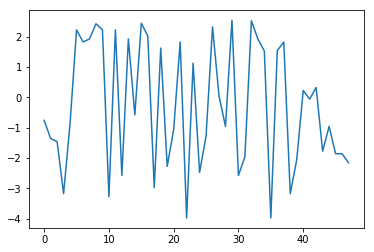

In [83]:
diff=y_test-y_pred
print(diff)
plt.plot(diff)
plt.show()


In [84]:

df=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})  
df 
df1=df.head(25)


In [85]:
from sklearn import metrics  
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred))) 


Mean Absolute Error: 1.8756579601990027
Mean Squared Error: 4.32674198461721
Root Mean Squared Error: 2.0800822062161894


In [86]:
y_pred1 = regressor.predict([[6.8,17.6,28.6,3]])
print(y_pred1)

[18.7704]


In [87]:
# Report the score of the prediction using the testing set
# It is simply the ratio of correct predictions divided by the total data points. 
accuracy = regressor.score(X_test,y_test)
print(accuracy*100,'%')

28.941787112497387 %


In [88]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.28941787112497386

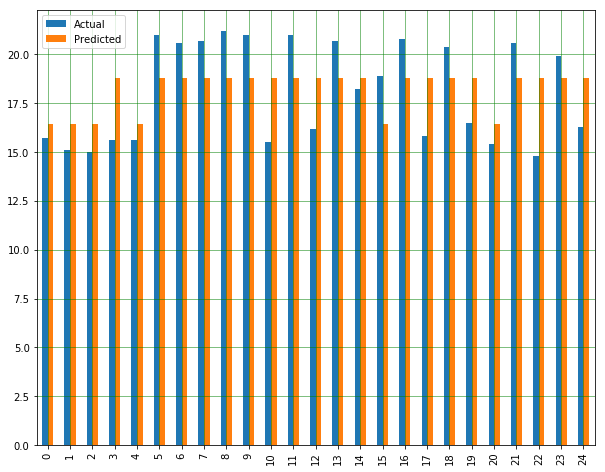

In [89]:
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [90]:

# #The mean absolute error for our algorithm is 17.8, which is less than 10 percent of the mean of all the values in the 'independent variables' column.
#This means that our algorithm did a fine prediction job.

In [91]:
import os     
os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz2.38/bin/'

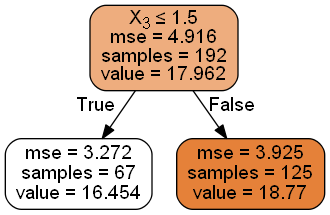

In [92]:
#visualizing decision tree
# export_graphviz function converts decision tree into dot file 
# and pydotplus convert this dot file to png or displayable form on Jupyter.




from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

dot_data = StringIO()

export_graphviz(regressor, out_file=dot_data, max_depth=3,
filled=True, rounded=True,
special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())



# out_file : file object or string, optional (default=None)
#Handle or name of the output file. If None, the result is returned as a string.

# max_depth : int, optional (default=None)
# The maximum depth of the representation. If None, the tree is fully generated.

# feature_names : list of strings, optional (default=None)
# Names of each of the features.

# filled : bool, optional (default=False)
# When set to True, paint nodes to indicate majority class for classification,
# extremity of values for regression, or purity of node for multi-output.

# rounded : bool, optional (default=False)
# When set to True, draw node boxes with rounded corners and use Helvetica fonts instead of Times-Roman.

# special_characters : bool, optional (default=False)
# When set to False, ignore special characters for PostScript compatibility.


# Returns:	dot_data : string
# String representation of the input tree in GraphViz dot format. Only returned if out_file is None.

# The ‘value’ row in each node tells us
# how many of the observations that were sorted into that node fall into each categories.

